## Day 4 – Evaluation

In [2]:
# Standalone setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.fft import fft, fftfreq

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)
if isinstance(smi_1min.columns, pd.MultiIndex):
    smi_1min.columns = smi_1min.columns.get_level_values(0)

price = smi_1min['Close'].dropna().values.astype(float)
time_index = smi_1min['Close'].dropna().index

# Standalone variables
reference_signal = price.copy()
N = len(reference_signal)
T_s = 60
f_s = 1 / T_s
time_seconds = np.arange(N) * T_s

downsample_factors = [1, 2, 5, 15, 60]
labels = ['D=1 (1 min, baseline)', 'D=2 (2 min, at Nyquist)',
          'D=5 (5 min, below)', 'D=15 (15 min, well below)',
          'D=60 (1 hour, severe)']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

sampled_signals = {}
for D, label in zip(downsample_factors, labels):
    sampled = reference_signal[::D]
    sampled_time = time_seconds[::D]
    effective_fs = f_s / D
    nyquist = effective_fs / 2
    sampled_signals[label] = {
        'signal': sampled,
        'time': sampled_time,
        'factor': D,
        'f_s': effective_fs,
        'f_nyquist': nyquist
    }

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_44948/2401035651.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)


### Evaluation Approach Definition

> **Metric 1 – RMSE (Root Mean Squared Error):** The selected metric is RMSE, which quantifies the point-wise amplitude deviation between the reconstructed (interpolated) sampled signal and the high-resolution reference. It is specifically chosen because the use case requires accurate amplitude reconstruction for volatility estimation, and RMSE directly reflects reconstruction fidelity. The metric is meaningful here because the original 1-minute signal serves as ground truth. RMSE is reported in CHF.

> **Metric 2 – Relative Volatility Error:** The second evaluation approach quantifies how downsampling affects the estimated realized volatility (standard deviation of log-returns). This metric is directly relevant to the financial risk monitoring use case because accurate volatility estimation is the primary objective. The relative volatility error is computed as $|(\sigma_{sampled} - \sigma_{ref}) / \sigma_{ref}| \times 100\%$.

### Evaluation Comparison Execution

> The influence of key parameter **downsampling factor D** was evaluated using RMSE and Relative Volatility Error. This parameter is essential for the defined use case because it directly affects the temporal resolution of the financial signal, which is critical for intraday risk assessment. Changes in both metrics across parameter settings quantify how sensitive volatility estimation is to sampling rate reduction. Relative performance change was computed with respect to the baseline configuration D = 1.


In [5]:
from scipy.interpolate import interp1d

def compute_rmse(reference, sampled_time, sampled_signal, ref_time):
    """Interpolate sampled signal back to reference time grid and compute RMSE."""
    interpolator = interp1d(sampled_time, sampled_signal, kind='linear', fill_value='extrapolate')
    reconstructed = interpolator(ref_time)
    rmse = np.sqrt(np.mean((reference - reconstructed)**2))
    return rmse, reconstructed

def compute_volatility(signal):
    """Compute realized volatility as std of log-returns."""
    log_returns = np.diff(np.log(signal))
    return np.std(log_returns)

ref_vol = compute_volatility(reference_signal)
ref_time = time_seconds

results = []
for label, data in sampled_signals.items():
    rmse, reconstructed = compute_rmse(reference_signal, data['time'], data['signal'], ref_time)
    vol = compute_volatility(data['signal'])
    vol_error = abs(vol - ref_vol) / ref_vol * 100
    results.append({
        'Configuration': label,
        'Factor': data['factor'],
        'Samples': len(data['signal']),
        'RMSE (CHF)': rmse,
        'Volatility': vol,
        'Rel. Vol. Error (%)': vol_error
    })

results_df = pd.DataFrame(results)
baseline_rmse = results_df.loc[0, 'RMSE (CHF)']
results_df['RMSE Change vs Baseline (%)'] = (
    (results_df['RMSE (CHF)'] - baseline_rmse) / max(baseline_rmse, 1e-10) * 100
)
print(results_df.to_markdown(index=False, floatfmt='.4f'))

| Configuration             |   Factor |   Samples |   RMSE (CHF) |   Volatility |   Rel. Vol. Error (%) |   RMSE Change vs Baseline (%) |
|:--------------------------|---------:|----------:|-------------:|-------------:|----------------------:|------------------------------:|
| D=1 (1 min, baseline)     |        1 |      3556 |       0.0000 |       0.0006 |                0.0000 |                        0.0000 |
| D=2 (2 min, at Nyquist)   |        2 |      1778 |       3.8114 |       0.0009 |               46.7945 |            3811356457301.8740 |
| D=5 (5 min, below)        |        5 |       712 |       6.8104 |       0.0015 |              137.9187 |            6810375452273.2383 |
| D=15 (15 min, well below) |       15 |       238 |      13.1689 |       0.0030 |              388.6881 |           13168949743734.0742 |
| D=60 (1 hour, severe)     |       60 |        60 |      27.1367 |       0.0059 |              859.3376 |           27136714376611.7148 |


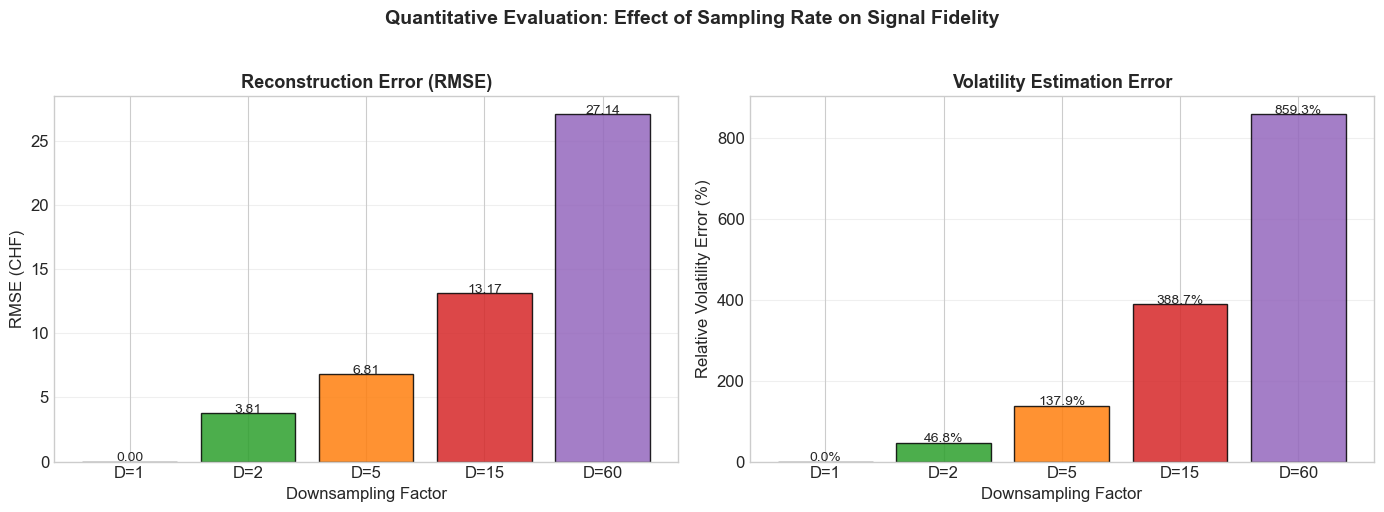

In [6]:
# Visualization: RMSE and Volatility Error as function of downsampling factor
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

factors = results_df['Factor'].values

ax1.bar(range(len(factors)), results_df['RMSE (CHF)'].values, color=colors, edgecolor='black', alpha=0.85)
ax1.set_xticks(range(len(factors)))
ax1.set_xticklabels([f'D={d}' for d in factors])
ax1.set_xlabel('Downsampling Factor', fontsize=12)
ax1.set_ylabel('RMSE (CHF)', fontsize=12)
ax1.set_title('Reconstruction Error (RMSE)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(results_df['RMSE (CHF)'].values):
    ax1.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

ax2.bar(range(len(factors)), results_df['Rel. Vol. Error (%)'].values, color=colors, edgecolor='black', alpha=0.85)
ax2.set_xticks(range(len(factors)))
ax2.set_xticklabels([f'D={d}' for d in factors])
ax2.set_xlabel('Downsampling Factor', fontsize=12)
ax2.set_ylabel('Relative Volatility Error (%)', fontsize=12)
ax2.set_title('Volatility Estimation Error', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(results_df['Rel. Vol. Error (%)'].values):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Quantitative Evaluation: Effect of Sampling Rate on Signal Fidelity',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()